In [1]:
import collections
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from itertools import chain
from sklearn.linear_model import LinearRegression
import os
import logging

In [2]:
from utils.DetectionTools import merge_close_points, get_detected_intervals
from utils.OutlierUtils import left_derivatives, get_region, remove_outliers_by_region, sanitize_response_name


In [3]:
concentrations = None
response = '' # Change this to select the response column
dataset_name = '*'
path_to_data = f'../data/ICP-MS/{dataset_name}.csv'
output_path = '../output'

In [4]:
# Parameters
concentrations = [1, 2, 3, 4, 5, 6, 7, 8]
dataset_name = "Stds-040325_CrNiFeMoMn"
path_to_data = "../data/ICP-MS/Stds-040325_CrNiFeMoMn.csv"
response = "Fe -/56(Pulse/CPS)"
output_path = "../output/Stds-040325_CrNiFeMoMn/Fe_-_56(Pulse_CPS)"


# Indicate the path to your data file here

In [5]:
# Import data
df = pd.read_csv(path_to_data)
t = df['Time']
response_data = df[response] if response else df.iloc[:, 1]  # Default to the second column if no response specified
df

,Replicate,Reading,Time,Cr -/52(Pulse/CPS),Mn -/55(Pulse/CPS),Fe -/56(Pulse/CPS),Ni -/60(Pulse/CPS),Mo -/98(Pulse/CPS)
0,1,1,0.000,140.000686,0.000000,1.240538e+04,920.029625,0.000000
1,1,2,0.324,100.000350,0.000000,1.376663e+04,1300.059153,0.000000
2,1,3,0.648,120.000504,0.000000,1.328618e+04,760.020217,20.000014
3,1,4,0.972,80.000224,40.000056,1.344633e+04,1140.045488,0.000000
4,1,5,1.296,180.001134,0.000000,1.270565e+04,1220.052096,0.000000
...,...,...,...,...,...,...,...,...
9152,1,9153,2965.357,151013.986235,18491.960600,1.706366e+06,54082.177458,13286.175414
9153,1,9154,2965.681,142325.464631,18852.431293,1.793944e+06,53580.291590,14267.120720
9154,1,9155,2966.005,151923.554062,17670.922397,1.797604e+06,53299.243191,13786.649301
9155,1,9156,2966.329,150993.774271,17791.071384,1.825965e+06,56350.921153,13166.064289


In [6]:
safe_name = sanitize_response_name(response)
figure_dir = f'{output_path}/figures/{safe_name}'

if not os.path.exists(figure_dir):
    os.makedirs(figure_dir, exist_ok=True)


In [7]:
# Identifying shifts with k-means
X = collections.deque(t)
Y = collections.deque(response_data)

In [8]:
# Normalize time
df['Time'] = df['Time'] - df['Time'].min()
df = df.loc[:, df.columns.intersection(['Time',f'{response}'])]
df_response_idxMax = df.idxmax()[response]
df = df.iloc[:df_response_idxMax+1]

df

,Time,Fe -/56(Pulse/CPS)
0,0.000,1.240538e+04
1,0.324,1.376663e+04
2,0.648,1.328618e+04
3,0.972,1.344633e+04
4,1.296,1.270565e+04
...,...,...
6967,2257.391,2.284928e+05
6968,2257.715,2.400399e+05
6969,2258.039,1.212957e+06
6970,2258.363,1.938187e+06


In [9]:
%matplotlib qt

clicked_coordinates = None # Variable to store the click location
left_derivatives_df = left_derivatives(df['Time'].to_numpy(), df[response].to_numpy())


def onclick(event):
    global clicked_coordinates # Declare it global to modify the outside variable
    if event.xdata is not None and event.ydata is not None:
        clicked_coordinates = (event.xdata, event.ydata)
        logging.info(f"Clicked at data coordinates: x={event.xdata}, y={event.ydata}")
        plt.close(fig) # Close the window

    else:
        logging.info("Click was outside the plot area.")

fig, ax1 = plt.subplots(figsize=(18, 12), layout='constrained') # Increased figure size for clarity
plt.scatter(df['Time'], df[response])

# Save derivative and data pllot
plt.savefig(f'{output_path}/Derivative-Data-Plot', bbox_inches='tight',dpi=300)

cid = fig.canvas.mpl_connect('button_press_event', onclick)

# Now your loop can run while the plot is interactive
logging.info("Waiting for a click...")
start_time = time.time()
timeout_seconds = 1000 # Your desired timeout

while True:
    if clicked_coordinates:
        logging.info(f"Click detected at: {clicked_coordinates}")
        break
    if (time.time() - start_time) > timeout_seconds:
        logging.info('Timed out. No click detected within the specified time.')
        break
    plt.pause(0.1) # Process GUI events for a short period
                   # This is crucial for interactive mode to work
plt.ioff() # Turn off interactive mode
plt.show() # Keep the plot open until manually closed after the loop

INFO: Waiting for a click...


INFO: Clicked at data coordinates: x=788.2756848886702, y=21931.334491195244


INFO: Click detected at: (788.2756848886702, 21931.334491195244)


In [10]:
%matplotlib inline

# After the window is closed, you can access the stored coordinates
if clicked_coordinates:
    logging.info(f"The final stored coordinates are: {clicked_coordinates}")
else:
    logging.info("No valid click was registered before the window closed.")

first_region = (np.array([0]).astype(float)[0], clicked_coordinates[0])
first_region

INFO: The final stored coordinates are: (788.2756848886702, 21931.334491195244)


(0.0, 788.2756848886702)

In [11]:
# Get left derivatives
left_derivatieves_df = left_derivatives_df[left_derivatives_df['Time'] > first_region[1]]
left_derivatives_df.set_index(['Time'], inplace=True)
left_derivatives_df

,Y,Left_Derivative
Time,,
0.000,1.240538e+04,NaN
0.324,1.376663e+04,4.201377e+03
0.648,1.328618e+04,-1.482885e+03
0.972,1.344633e+04,4.942893e+02
1.296,1.270565e+04,-2.286042e+03
...,...,...
2257.391,2.284928e+05,-2.322919e+05
2257.715,2.400399e+05,3.563905e+04
2258.039,1.212957e+06,3.002831e+06


In [12]:
# Define the first region
mask1 = (left_derivatives_df['Left_Derivative'] > left_derivatives_df['Y'])
shifts = left_derivatives_df[mask1]
mask2 = (shifts.index > first_region[1])
shifts = shifts[mask2]

shifts = list(shifts.index)

shifts

[790.265,
 975.276,
 975.6,
 1205.324,
 1205.648,
 1495.963,
 1688.75,
 1689.074,
 1929.491,
 1929.815,
 2106.078,
 2106.402,
 2258.039,
 2258.363]

In [13]:
detected_intervals = get_detected_intervals(shifts)
detected_intervals.append((first_region[1], detected_intervals[0][0]))
detected_intervals.append((first_region[0], first_region[1])) # Add the first region
detected_intervals = sorted(detected_intervals)

detected_intervals.append((detected_intervals[-1][1], df['Time'].max())) # Add the last region
detected_intervals


[(0.0, 788.2756848886702),
 (788.2756848886702, 790.265),
 (790.265, 975.276),
 (975.276, 975.6),
 (975.6, 1205.324),
 (1205.324, 1205.648),
 (1205.648, 1495.963),
 (1495.963, 1688.75),
 (1688.75, 1689.074),
 (1689.074, 1929.491),
 (1929.491, 1929.815),
 (1929.815, 2106.078),
 (2106.078, 2106.402),
 (2106.402, 2258.039),
 (2258.039, 2258.363),
 (2258.363, 2258.687)]

# Select a p value here

In [14]:
p = 60 # Change this to select the p value for merging close points

In [15]:
merged_points = merge_close_points(df=df, regions=detected_intervals, p=p, response=response)
merged_points_list = sorted(list(set(tuple(chain.from_iterable(merged_points)))))
merged_points

Merged tiny region (788.2756848886702, 790.265) with previous region (0.0, 788.2756848886702) -> (0.0, 790.265)
Merged tiny region (975.276, 975.6) with previous region (790.265, 975.276) -> (790.265, 975.6)
Merged tiny region (1205.324, 1205.648) with previous region (975.6, 1205.324) -> (975.6, 1205.648)
Merged tiny region (1688.75, 1689.074) with previous region (1495.963, 1688.75) -> (1495.963, 1689.074)
Merged tiny region (1929.491, 1929.815) with previous region (1689.074, 1929.491) -> (1689.074, 1929.815)
Merged tiny region (2106.078, 2106.402) with previous region (1929.815, 2106.078) -> (1929.815, 2106.402)
Merged tiny region (2258.039, 2258.363) with previous region (2106.402, 2258.039) -> (2106.402, 2258.363)
Merged tiny region (2258.363, 2258.687) with previous region (2106.402, 2258.363) -> (2106.402, 2258.687)
Starting merge with 8 regions, p-value: 60
First region: (0.0, 790.265), median: 14046.9026479612
Comparing region 1: (790.265, 975.6), median: 26143.9007540694
  -

[(0.0, 790.265),
 (790.265, 1205.648),
 (1205.648, 1495.963),
 (1495.963, 1689.074),
 (1689.074, 1929.815),
 (1929.815, 2106.402),
 (2106.402, 2258.687)]

## Final Plot

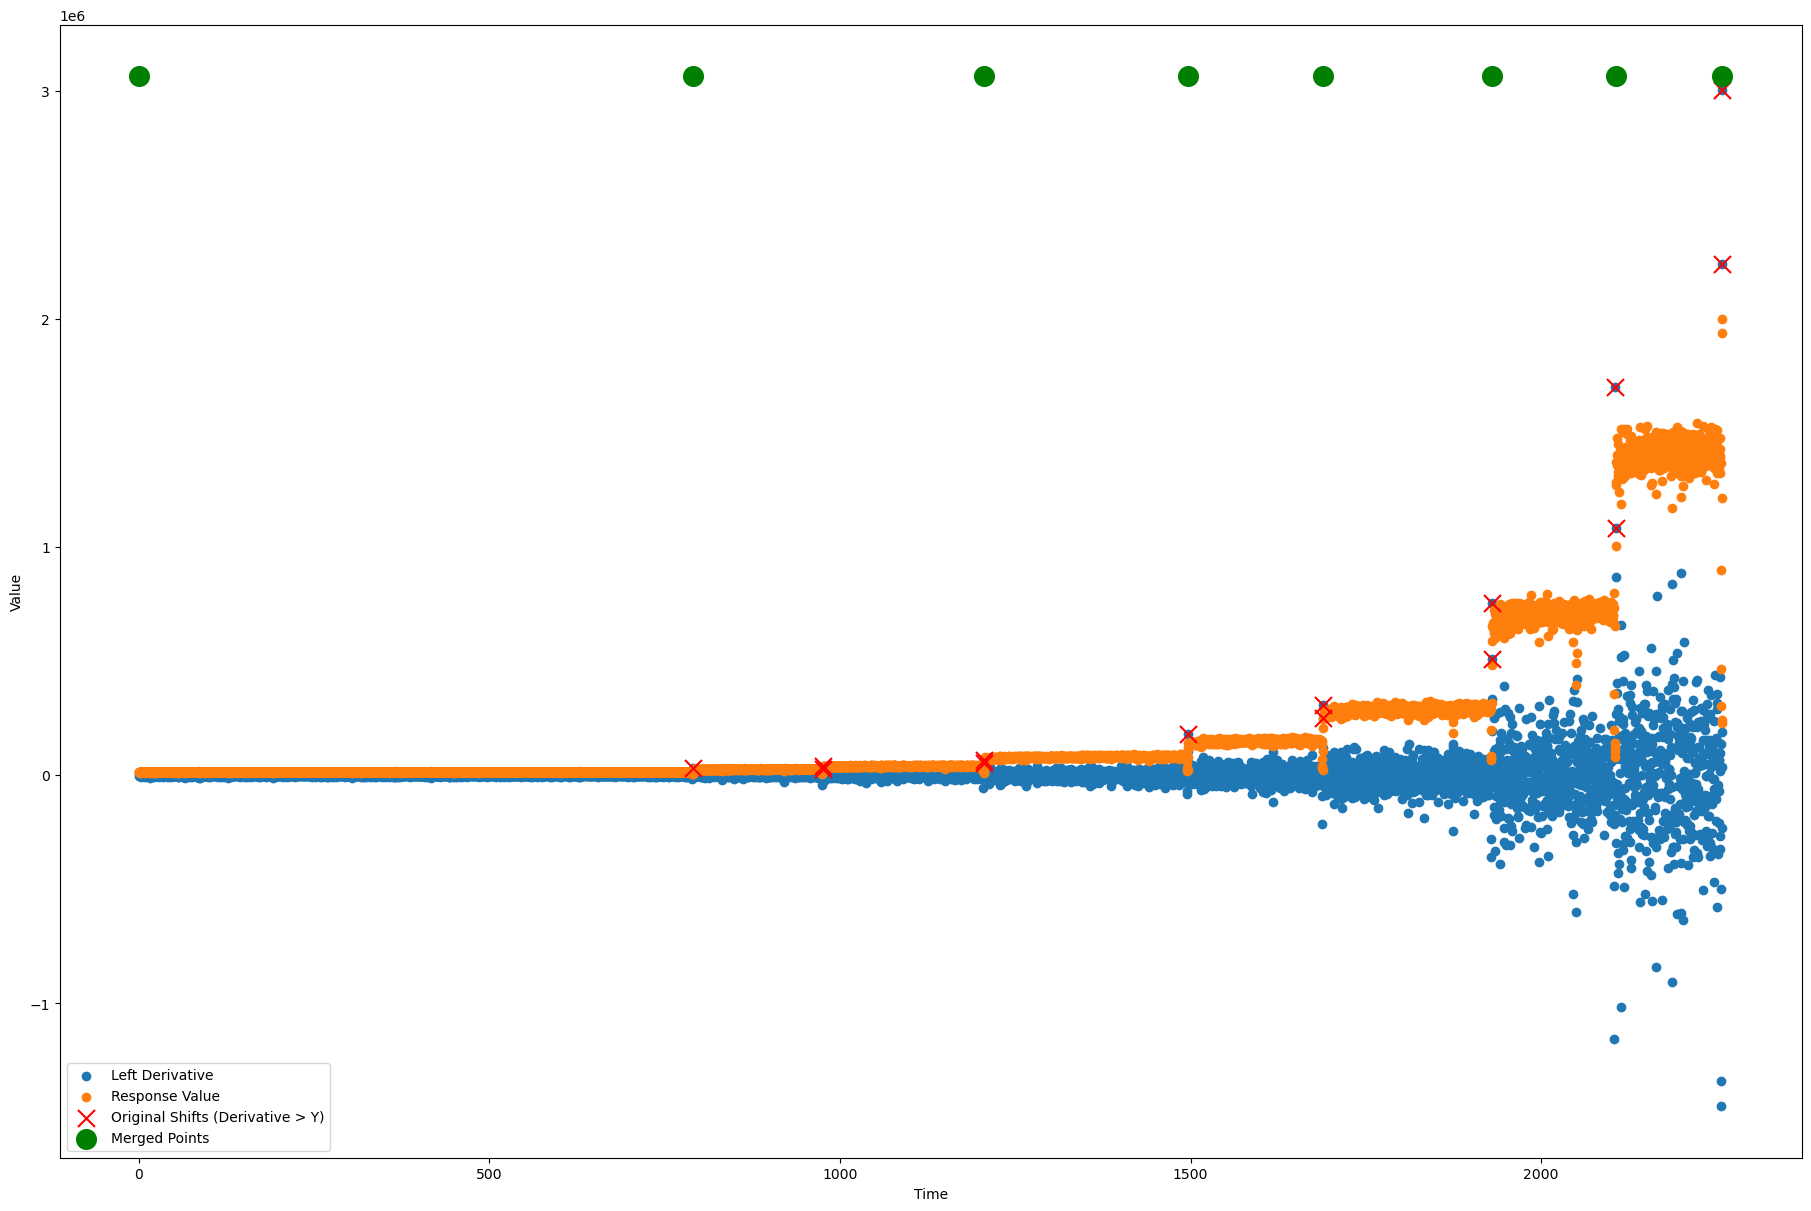

In [16]:
fig, ax1 = plt.subplots(figsize=(18, 12), layout='constrained')

# Plot original data and derivatives
ax1.scatter(left_derivatives_df.index, left_derivatives_df['Left_Derivative'], label='Left Derivative')
ax1.scatter(df['Time'], df[response], label='Response Value')

# Plot the original 'shifts' as red 'x' marks
ax1.scatter(shifts,
            left_derivatives_df.loc[shifts, 'Left_Derivative'],
            marker='x', color='red', s=150, zorder=4, label='Original Shifts (Derivative > Y)')


# Add the merged points to the plot as green circles
ax1.scatter(merged_points_list, [ax1.get_ylim()[1] * 0.95] * len(merged_points_list),
            marker='o', color='green', s=200, zorder=5, label='Merged Points') # Plot high up to be visible'

ax1.set_xlabel('Time')
ax1.set_ylabel('Value')
ax1.legend()
plt.savefig(f'{figure_dir}/Regional-Final.png',bbox_inches='tight',dpi=300)
plt.show()


get_region called with t0=0.0, tf=788.2756848886702. Filtered DataFrame shape: (2433, 2)
get_region called with t0=15.0, tf=773.2756848886702. Filtered DataFrame shape: (2340, 2)
get_region called with t0=788.2756848886702, tf=790.265. Filtered DataFrame shape: (7, 2)
get_region called with t0=803.2756848886702, tf=775.265. Filtered DataFrame shape: (0, 2)
get_region called with t0=790.265, tf=975.276. Filtered DataFrame shape: (572, 2)
get_region called with t0=805.265, tf=960.276. Filtered DataFrame shape: (478, 2)
get_region called with t0=975.276, tf=975.6. Filtered DataFrame shape: (2, 2)
get_region called with t0=990.276, tf=960.6. Filtered DataFrame shape: (0, 2)
get_region called with t0=975.6, tf=1205.324. Filtered DataFrame shape: (710, 2)
get_region called with t0=990.6, tf=1190.324. Filtered DataFrame shape: (616, 2)
get_region called with t0=1205.324, tf=1205.648. Filtered DataFrame shape: (2, 2)
get_region called with t0=1220.324, tf=1190.648. Filtered DataFrame shape: (0

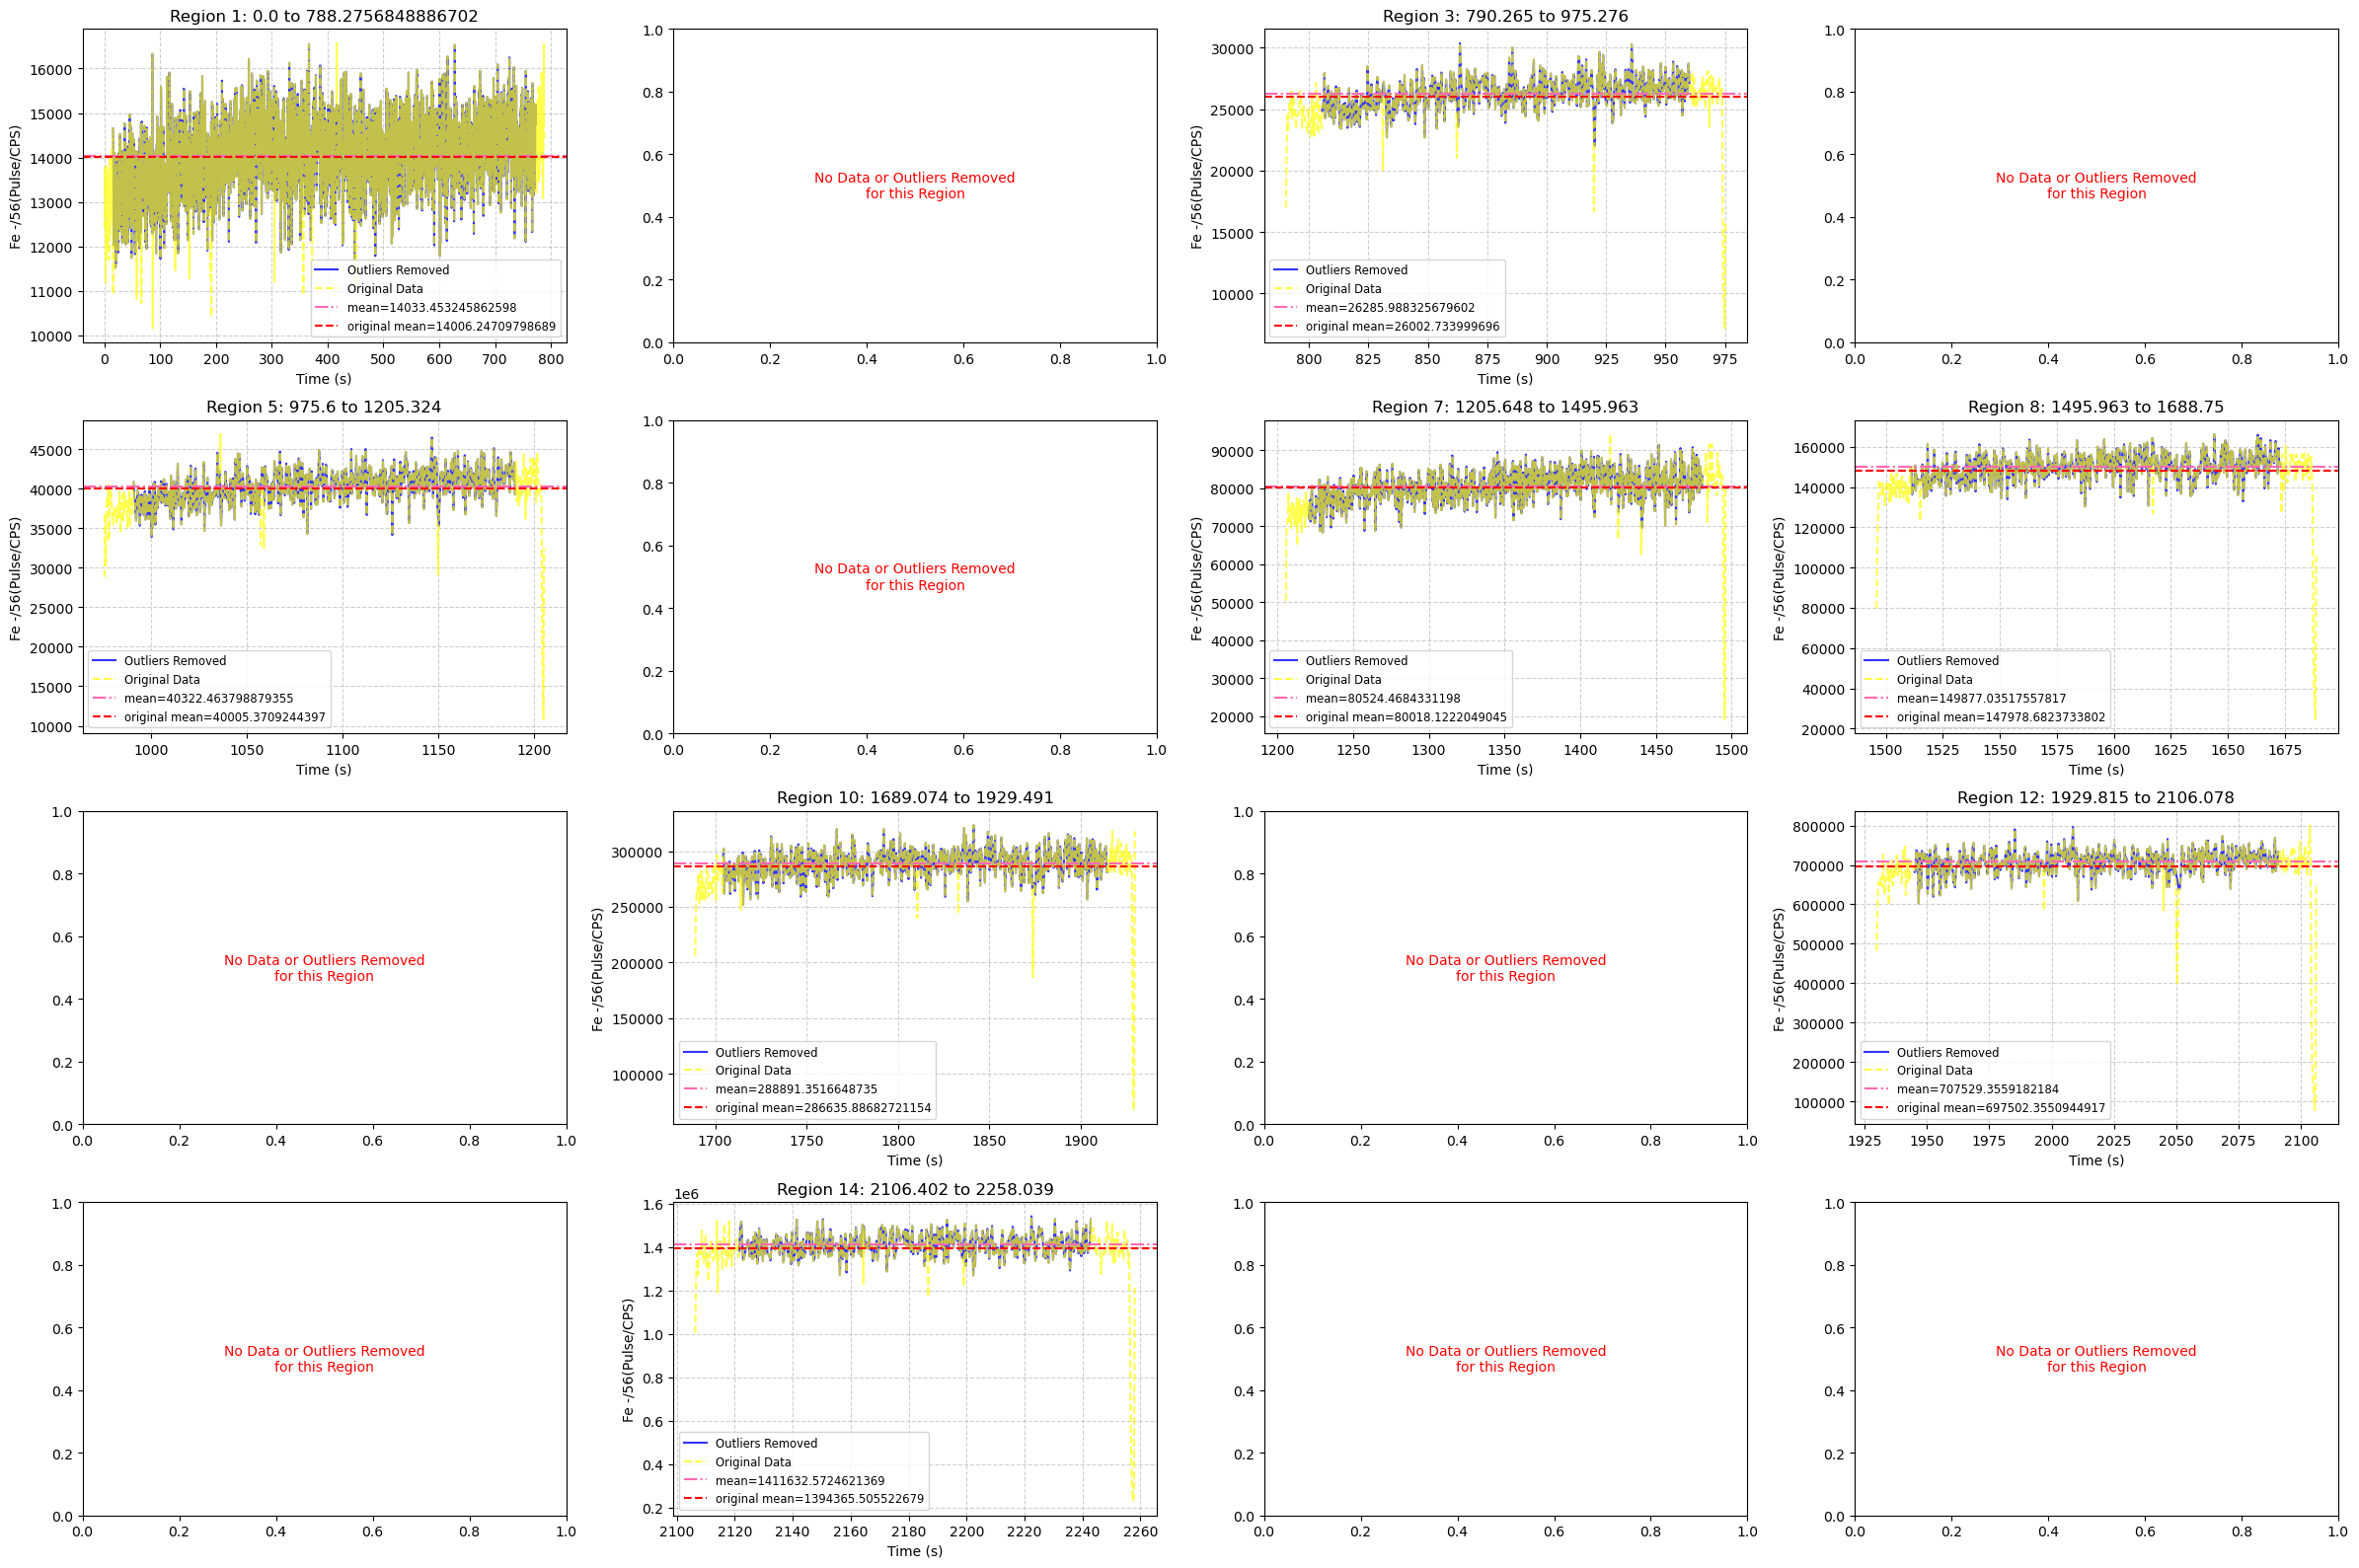

In [17]:
regional_means = []

num_regions = len(detected_intervals)
ncols = 4 # You can change the number of columns
nrows = (num_regions + ncols - 1) // ncols

offset = 15 # 15 seconds offset to 

final_df = pd.DataFrame()


fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(24, 4 * nrows))
axes_flat = axes.flatten() # Flatten the 2D axes array for easier iteration
for i, (x0, x1) in enumerate(detected_intervals):
    # Get the current Axes object for this iteration from the flattened array
    if i < len(axes_flat):
        current_ax = axes_flat[i]
    else:
        # This case should ideally not happen if nrows is calculated correctly,
        # but provides a safeguard if more plots are attempted than subplots available.
        logging.warning(f" Not enough subplots for region {i+1}. Skipping plot.")
        continue
    

    # Call your outlier removal function for the current region
    original_region_data = get_region(df=df, t0=x0, tf=x1)
    Y_prime = remove_outliers_by_region(R=(x0 + offset, x1 - offset), response_column_name=response, Y=df)

    # logging.info(f'New Region {i+1}: ({val['Start'] + offset}, {val['End'] - offset})')

    # Plot the results on the current subplot
    if not Y_prime.empty:
        # Plot the data after outlier removal
        current_ax.plot(Y_prime['Time'], Y_prime[response], label='Outliers Removed', color='blue', alpha=0.8)
        
        # Plot original data for comparison (only within the current region)

        
        current_ax.plot(original_region_data['Time'], original_region_data[response],
                        '--', color='yellow', alpha=0.7, label='Original Data')
        
        region_mean = Y_prime[response].mean()
        original_mean = original_region_data[response].mean()
        
        current_ax.axhline(y=region_mean, color='#FF69B4', linestyle='-.', label=f'mean={region_mean}')
        current_ax.axhline(y=original_mean, color='red', linestyle='--', label=f'original mean={original_mean}')

        regional_means.append(region_mean)
        
        current_ax.legend(fontsize='small')
    else:
        current_ax.text(0.5, 0.5, 'No Data or Outliers Removed\nfor this Region',
                        horizontalalignment='center', verticalalignment='center',
                        transform=current_ax.transAxes, fontsize=10, color='red')
        continue

    # Set titles and labels for the current subplot
    current_ax.set_title(f'Region {i+1}: {x0} to {x1}')
    current_ax.set_xlabel('Time (s)')
    current_ax.set_ylabel(f'{response}')
    current_ax.grid(True, linestyle='--', alpha=0.6) # Add a grid for better readability

    final_df = pd.concat([final_df, Y_prime], ignore_index=True)



# This prevents empty plots from appearing if your `area_df` has fewer regions than the grid size
for j in range(num_regions, len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.savefig(f'{figure_dir}/regions.png',
             bbox_inches='tight',
             dpi=300)
plt.tight_layout() # Automatically adjust subplot parameters for a tight layout
plt.show() # Display the plot
    
# plt.tight_layout()
# plt.show()

In [18]:
final_df = final_df.sort_index()
final_df

,Time,Fe -/56(Pulse/CPS)
0,15.228,1.464751e+04
1,15.876,1.352640e+04
2,16.200,1.314605e+04
3,16.524,1.300592e+04
4,16.848,1.202506e+04
...,...,...
6170,2241.515,1.406137e+06
6171,2241.839,1.373345e+06
6172,2242.163,1.403385e+06
6173,2242.487,1.414550e+06


In [19]:
# Plot regional means
labels = np.array(concentrations)

data = pd.DataFrame(labels, regional_means)
data.to_csv(f'{output_path}/RegionalData.csv')
display(data.index)
display(data.values)

Index([14033.453245862598, 26285.988325679602, 40322.463798879355,
         80524.4684331198, 149877.03517557817,  288891.3516648735,
        707529.3559182184, 1411632.5724621369],
      dtype='float64')

array([[1],
       [2],
       [3],
       [4],
       [5],
       [6],
       [7],
       [8]])

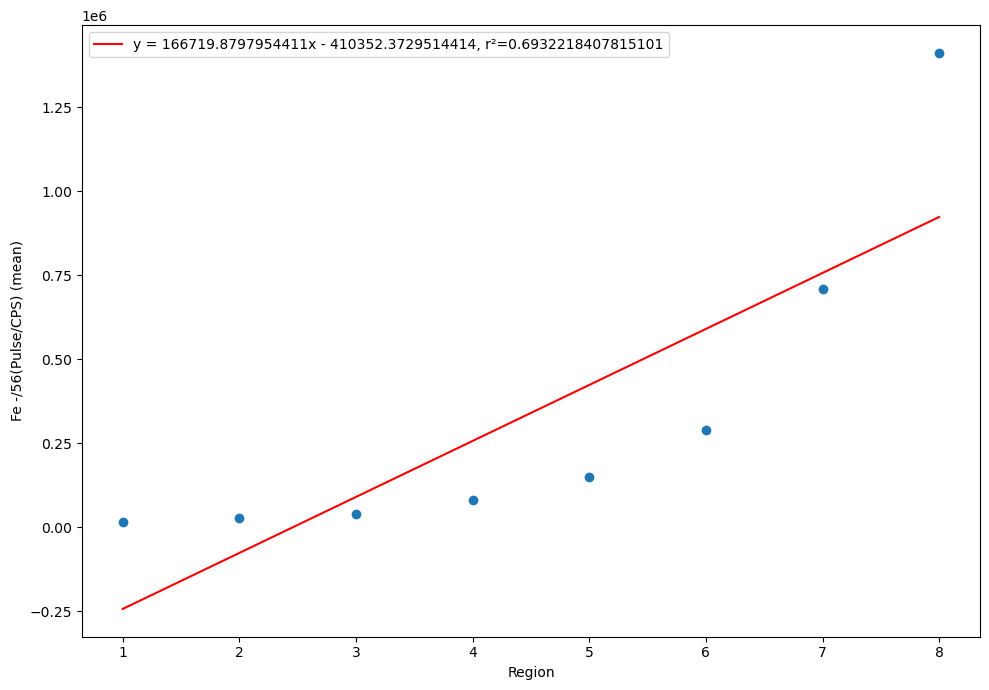

In [20]:
fig, ax1 = plt.subplots(figsize=(10, 7))

# Plot the bars
ax1.scatter(data.values, data.index)  # Convert index to string for proper label display
m,b = np.polyfit(labels, regional_means , 1)


model = LinearRegression()

X = labels.reshape(-1, 1)
y = np.array(regional_means)

model.fit(X,y)

r_squared = model.score(X,y)


# Find regression equation
if b >= 0:
    line_label = f'y = {m}x + {b}'
else:
    line_label = f'y = {m}x - {-b}' # Use -b to show a positive number after the minus sign

ax1.plot(labels, m*labels + b, color='red', label=f'{line_label}, r²={r_squared}')


plt.legend()

ax1.set_xlabel('Region')
ax1.set_ylabel(f'{response} (mean)')



plt.tight_layout()
plt.savefig(f'{figure_dir}/Regression-Plot.png', bbox_inches='tight',dpi=300)
plt.show()


$$ \textit{Opus ex amino, } \\ \text{Bhagawat Chapagain} $$